# Assignment 1: Similarity Metrics for Collaborative Filtering
**Team:** Farah Ali 9281, Yasmin Haytham 9324, Yahya Ali 9351

**Dataset citation:** F. Maxwell Harper and Joseph A. Konstan, "The MovieLens Datasets: History and Context," ACM TiiS, 2015.

**AI disclosure:** This skeleton (headings, function signatures, docstrings, TODO markers) was AI-generated. Every other piece of code is written by the team. Any further AI-generated section must be wrapped in `# AI-GENERATED START` / `# AI-GENERATED END` comments.

**Ownership:** P1 = Parts A, B, Q17 | P2 = Parts C, D, Q12, Q18, Bonus 1 (mean-centering) | P3 = Part E, Q16, Bonus 2 (top-10 list)

**Shared conventions (agree before coding):** `matrix` is a pandas DataFrame, rows = userId, columns = movieId, NaN = not rated. Function signatures exactly as in the PDF. Similarity functions take two aligned numpy arrays. Return `None` (not 0) when a prediction is impossible.

In [1]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Part A: Load and explore  *(Owner: P1)*

In [7]:
# Loading data 
ratings = pd.read_csv('data/ratings.csv',usecols={0,1,2})
movies = pd.read_csv('data/movies.csv')

# Part A (2):

In [ ]:
uniqueUsers = ratings['userId'].nunique()
uniqueMovies = ratings['movieId'].nunique()
numOfRatings = len(ratings)
numOfCells =  uniqueUsers * uniqueMovies
sparsity = 1 - (numOfRatings/numOfCells)
print(uniqueUsers)
print(uniqueMovies)
print(numOfRatings)
print(numOfCells)
print(f"{sparsity:.4f}")

610
9724
100836
5931640
0.9830


# Part A (3):

In [31]:
matrix = ratings.pivot_table(
    index= 'userId',
    columns= 'movieId',
    values= 'rating'
)
# AI-GENERATED START
print(matrix.shape) # sanity check recommended by AI
# AI-GENERATED END

(610, 9724)


# Part A (4):

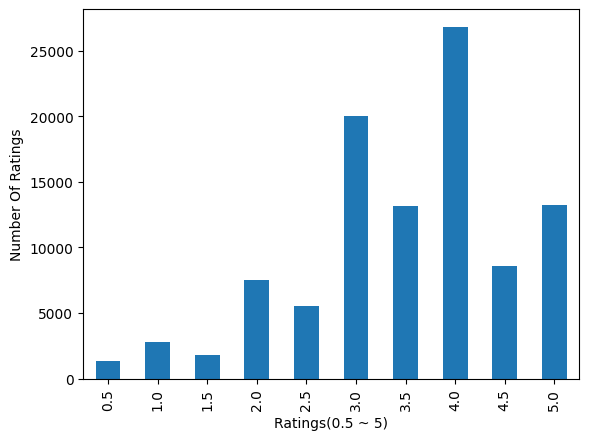

In [ ]:
ratingsCount = ratings['rating'].value_counts().sort_index()
ratingsCount.plot(kind='bar')
plt.xlabel('Ratings(0.5 ~ 5)')
plt.ylabel('Number Of Ratings')
plt.title('Distribution of ratings')
plt.show()

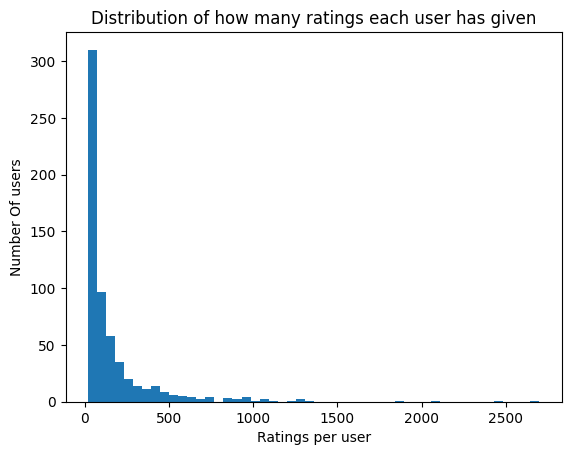

In [34]:
ratingsPerUser = ratings.groupby('userId').size()
plt.hist(ratingsPerUser,bins=50)
plt.xlabel('Ratings per user')
plt.ylabel('Number Of users')
plt.title('Distribution of how many ratings each user has given')
plt.show()

**What do you notice?** 


1 - Distribution of ratings plot shows that most users are generous users with 4.0 rating being the most given rating. 


2 - Distribution of how many ratings each user has given plot shows that most users tend to rate only a few number of movies they watched which supports the sparsity value calculated above were almost 98% of the ratings not given. 

# Part B: Similarity metrics from scratch  *(Owner: P1)*
Only co-rated entries. No sklearn / scipy similarity functions.

In [ ]:
def get_co_rated(matrix, a, b, axis):
    if axis == 'index':
        vectorA = matrix.loc[a]
        vectorB = matrix.loc[b]
    elif axis == 'columns':
        vectorA = matrix[a]
        vectorB = matrix[b]

    co_rated = vectorA.notna() & vectorB.notna()
    return vectorA[co_rated], vectorB[co_rated]

def euclidean_similarity(vecA, vecB):
    euclidean_dis = np.sqrt(np.sum((vecA - vecB)**2))
    return 1 / (1 + euclidean_dis)
    
def cosine_similarity(vecA, vecB):
    dot_product = np.dot(vecA,vecB)
    normA = np.sqrt(np.sum(vecA**2))
    normB = np.sqrt(np.sum(vecB**2))
    return dot_product / (normA * normB)
   

def pearson_similarity(vecA, vecB):
    meanA = np.mean(vecA)
    meanB = np.mean(vecB)
    centeredA = vecA - meanA
    centeredB = vecB - meanB
    return cosine_similarity(centeredA,centeredB)



0.2
0.9871639953033075
1.0


In [ ]:
# Sanity check on the Section 3.2 example. Expected: Euclidean 0.2, cosine ~0.987, Pearson 1.0
userA = np.array([5,4,5,3])
userB = np.array([3,2,3,1])
print(euclidean_similarity(userA,userB))
print(cosine_similarity(userA,userB))
print(pearson_similarity(userA,userB))

0.2
0.9871639953033075
1.0


# Part C: User-based CF  *(Owner: P2)*

In [ ]:
def find_k_nearest_users(matrix, target_user, k, similarity_fn):
    """Return [(user_id, score), ...] sorted descending.
    Skip users with fewer than 2 co-rated items with target_user."""
    # TODO
    raise NotImplementedError

def predict_rating_user_based(matrix, target_user, target_item, k, similarity_fn):
    """Similarity-weighted average (Section 3.5) over neighbors who rated target_item.
    Return None if none of the k neighbors rated it."""
    # TODO
    raise NotImplementedError

# Part D: Item-based CF  *(Owner: P2)*

In [ ]:
def find_k_nearest_items(matrix, target_item, k, similarity_fn):
    # TODO
    raise NotImplementedError

def predict_rating_item_based(matrix, target_user, target_item, k, similarity_fn):
    # TODO
    raise NotImplementedError

**Q12:** Which Part C functions did you reuse, and what changed? (1-2 sentences)

# Part E: Evaluation  *(Owner: P3)*

In [ ]:
def train_test_split_ratings(ratings_df, test_fraction=0.2, seed=42):
    """Hold out test_fraction of EACH user's ratings. Return (train_df, test_df)."""
    # TODO
    raise NotImplementedError

def evaluate(matrix, test_df, k, similarity_fn, method):
    """method in {'user', 'item'}.
    Return dict: rmse, mae, fraction_none (over all test rows)."""
    # TODO
    raise NotImplementedError

In [ ]:
# TODO: build train matrix from train_df ONLY (never from the full data)
# TODO: run grid {user,item} x {euclidean,cosine,pearson} x k in {5,10,20,50}
# TIP: grid is slow. Test on a small sample of test_df first, then run in full.
results = []
# results_df = pd.DataFrame(results); display(results_df)

# Part F: Analysis (written, no new code)
**Q16 (P3):** Best metric? Matches Section 3.2 intuition? Where did it disagree?

**Q17 (P1):** Own example (2 users, 3-4 items) where Euclidean similarity and Pearson rank the same pair differently. Show calculation.

**Q18 (P2):** 200M users vs 20K products: which comparison is cheaper to keep updated, and why does it explain item-based CF in industry?

# Bonus 1: Mean-centered user-based CF  *(Owner: P2)*

In [ ]:
def predict_rating_user_based_centered(matrix, target_user, target_item, k, similarity_fn):
    """Subtract each neighbor's mean rating, take the weighted average of the centered ratings,
    then add the target user's mean back. Return None if no neighbor rated target_item."""
    # TODO
    raise NotImplementedError

In [ ]:
# TODO: compute RMSE of this vs plain Pearson-weighted prediction (reuse evaluate from Part E)

**Comparison and explanation:** why are the two closely related? (written)

# Bonus 2: Top-10 recommendations  *(Owner: P3)*

In [ ]:
def top_n_recommendations(matrix, target_user, n, k, similarity_fn, method):
    """Highest predicted ratings among items target_user has NOT rated. Return [(movieId, predicted)]."""
    # TODO
    raise NotImplementedError

In [ ]:
# TODO: pick one user, print top-10 with titles/genres from movies, and compare with that user's rating history

**Genre sanity check by hand** (written)